In [1]:
# MK: Importing essential project libraries - processing & visualization
import os
import re
import hashlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import librosa

In [2]:
# MK: Set data directory path for raw data, as raw data is not part of the repo. THIS MIGHT BE DIFFERENT ON YOUR MACHINE, PLEASE ADJUST ACCORDINGLY
# MK: CatSound_originals.zip from the team drive, unzipped. 2953 files, no augmented clones, no exact duplicates (team decision 08.09.)
data_dir = "../data/raw/CatSound_originals"

In [3]:
# MK: Get all classes (subdirs) in the data directory and sort them
classes = []
for name in os.listdir(data_dir):
    if os.path.isdir(data_dir + "/" + name):
        classes.append(name)
classes.sort()
classes

['Angry',
 'Defence',
 'Fighting',
 'Happy',
 'HuntingMind',
 'Mating',
 'MotherCall',
 'Paining',
 'Resting',
 'Warning']

In [4]:
# MK: Create a dataframe with all the audio files and their corresponding labels
labels = []
filenames = []

for label in classes:
    folder = data_dir + "/" + label
    for filename in os.listdir(folder):
        if filename.endswith(".mp3"):
            labels.append(label)
            filenames.append(filename)

df = pd.DataFrame()
df["label"] = labels
df["filename"] = filenames

print(len(df))
df.head()

2953


,label,filename
0,Angry,car_extcoll0177.mp3
1,Angry,YashLL_Cat0274Ang.mp3
2,Angry,LastEntry_cat1265Ang.mp3
3,Angry,cat_flickr01407.mp3
4,Angry,Cat_angry1021.mp3


In [5]:
df["label"].value_counts().sort_index()

label
Angry          300
Defence        291
Fighting       299
Happy          295
HuntingMind    289
Mating         300
MotherCall     296
Paining        287
Resting        296
Warning        300
Name: count, dtype: int64

In [6]:
# MK: samples are not perfectly balanced across classes (287 to 300), but close enough that we don't need to rebalance

In [7]:
# MK: Exact duplicates: same file content under a different name. md5 is a fingerprint of the file bytes, identical files give an identical md5
md5s = []

for i in range(len(df)):
    path = data_dir + "/" + df["label"][i] + "/" + df["filename"][i]
    file_bytes = open(path, "rb").read()
    md5s.append(hashlib.md5(file_bytes).hexdigest())

df["md5"] = md5s

md5_counts = df["md5"].value_counts()
duplicates = df[df["md5"].isin(md5_counts[md5_counts > 1].index)]
print(len(duplicates))
duplicates.sort_values("md5")

0


,label,filename,md5


In [8]:
# MK: The V2 zip had 7 duplicate pairs (14 files), one of them across two classes (Fighting/Online_Cat0341Ang = Paining/Online_Cat0368ang).
# MK: Those 8 files were removed when building CatSound_originals.zip, so this cell should show 0. If it doesn't, you have the wrong zip.

In [9]:
# MK: Segments: some recordings were cut into several files, the authors numbered them "name (1).mp3", "name (2).mp3", ...
# MK: Same cat, same video, so they have to stay together in the split. The group key is the filename without the " (n)" and "_opt" suffix
def group_key(filename):
    key = filename.replace(".mp3", "")
    key = re.sub(r"\s*\(\d+\)$", "", key)   # MK: remove " (1)", "(2)", ... at the end
    key = key.replace("_opt", "")
    return key.lower()

groups = []
for i in range(len(df)):
    groups.append(df["label"][i] + "/" + group_key(df["filename"][i]))
df["group"] = groups

group_sizes = df["group"].value_counts()
multi = group_sizes[group_sizes > 1]
print(len(df["group"].unique()), "groups for", len(df), "files")
print(len(multi), "groups with more than one file,", multi.sum(), "files involved")
multi.head(10)

2823 groups for 2953 files
91 groups with more than one file, 221 files involved


group
Fighting/yashll_conf_cat0261fit    24
Angry/fight_confusion               9
Angry/online_cat0533veryang         3
Defence/lastentry_cat1363hiss       3
Fighting/yashll_cat0243fit          3
HuntingMind/cat_youtubellt42402     3
HuntingMind/last_addcat193chat      3
Mating/cat_youtube64353             3
Mating/lastentry_cat1021mat         3
Resting/purr4                       3
Name: count, dtype: int64

In [ ]:
# MK: 91 groups with more than one file, 221 files in total - same recording, cut into pieces. Biggest group: 24 pieces of one video.
# MK: Only works for files with a "(n)" suffix. Pieces without it look like single files, so 221 is the floor, not the real number.

In [11]:
durations = []

for i in range(len(df)):
    path = data_dir + "/" + df["label"][i] + "/" + df["filename"][i] # MK: get the path to the audio file
    duration = librosa.get_duration(path=path)                       # MK: get the duration of the audio file
    durations.append(duration)

df["duration"] = durations                                           # MK: add the duration column to the dataframe
df.head()

,label,filename,md5,group,duration
0,Angry,car_extcoll0177.mp3,8d7030bab4e87645f588ce79fe45cbb7,Angry/car_extcoll0177,7.053923
1,Angry,YashLL_Cat0274Ang.mp3,0d1cbef144f246f6e831ec47fc5f1708,Angry/yashll_cat0274ang,4.702902
2,Angry,LastEntry_cat1265Ang.mp3,2c02e4f651f064e0ace40677cc33f2d3,Angry/lastentry_cat1265ang,8.281678
3,Angry,cat_flickr01407.mp3,f4f70ca86882f580ede9d6ed1d58a49d,Angry/cat_flickr01407,3.344535
4,Angry,Cat_angry1021.mp3,a4dc70cfa9dc6ce66d5d5f6e6fb06d9a,Angry/cat_angry1021,2.169025


In [12]:
df.groupby("label")["duration"].mean()

label
Angry          4.473289
Defence        1.749885
Fighting       3.629770
Happy          2.878326
HuntingMind    4.346337
Mating         4.932606
MotherCall     4.138065
Paining        3.824678
Resting        5.047331
Warning        3.629035
Name: duration, dtype: float64

In [13]:
df.groupby("label")["duration"].median()

label
Angry          4.206576
Defence        1.489841
Fighting       3.370658
Happy          2.822086
HuntingMind    4.232698
Mating         4.742086
MotherCall     4.180454
Paining        3.631882
Resting        4.977188
Warning        3.305351
Name: duration, dtype: float64

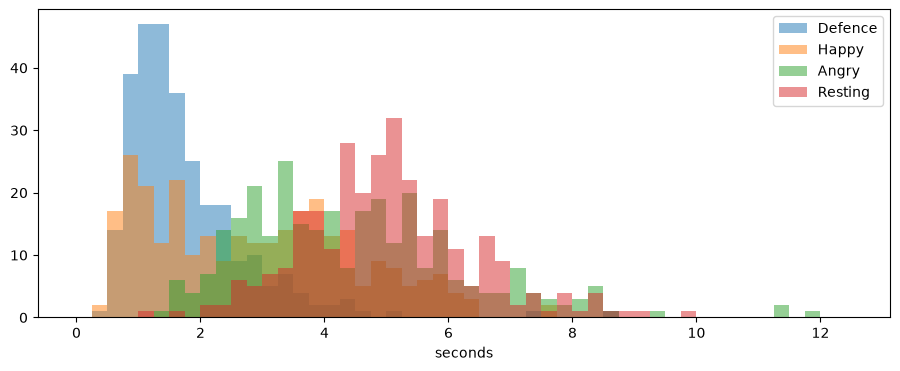

In [14]:
plt.figure(figsize=(11, 4)) # MK figsize defines the size of the figure in inches (width, height)

for label in ["Defence", "Happy", "Angry", "Resting"]:
    subset = df[df["label"] == label] # MK: get the subset of the dataframe for each label
    plt.hist(subset["duration"], bins=50, range=(0, 12.5), alpha=0.5, label=label) # MK: one histogram layer per class, alpha=0.5 so the four classes stay visible on top of each other

plt.xlabel("seconds")
plt.legend()

In [15]:
short = df[df["duration"] < 1] # MK: get the audio files with duration less than 1 second
short["label"].value_counts()

label
Defence       54
Happy         45
Fighting       3
MotherCall     3
Paining        3
Warning        2
Name: count, dtype: int64

In [16]:
# MK: In essence: Duration is a shortcut: Defence mostly under 2 s, Resting mostly over 4 s. A model can read the class off the silence, not the sound.
# MK: Suggestion: Snip out the X milliseconds around the loudest part of the audio file, and then optinally pad with silence to a fixed length.